In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


In [5]:
df.shape

(301355, 5)

In [6]:
df.describe()

,Склад,Количество
count,301355.000000,301355.000000
mean,2.900652,2.951559
std,1.352221,2.998154
min,1.000000,0.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,4.000000
max,5.000000,200.000000


In [7]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [12]:
df['Дата'] = pd.to_datetime(df['Дата'], dayfirst=True)

In [14]:
print(df)

             Дата  Склад   Контрагент Номенклатура  Количество
0      2018-01-04      1    address_0    product_0           4
1      2018-01-04      1    address_0    product_1           4
2      2018-01-04      1    address_0    product_2           5
3      2018-01-04      1    address_0    product_3          10
4      2018-01-04      1    address_0    product_4           2
...           ...    ...          ...          ...         ...
301350 2018-08-31      5  address_173   product_15           0
301351 2018-08-31      5  address_173   product_17           1
301352 2018-08-31      5  address_173   product_18           1
301353 2018-08-31      5  address_173   product_19           0
301354 2018-08-31      5  address_173   product_20           2

[301355 rows x 5 columns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [15]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

print(grouped_df)

          Дата  Количество продаж
0   2018-01-04               1840
1   2018-01-05               1301
2   2018-01-06               1306
3   2018-01-07               1322
4   2018-01-09               1719
..         ...                ...
200 2018-08-26               1462
201 2018-08-28               1731
202 2018-08-29               1497
203 2018-08-30               1445
204 2018-08-31               1366

[205 rows x 2 columns]


Вывести несколько первых строк сгруппированных данных

In [16]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

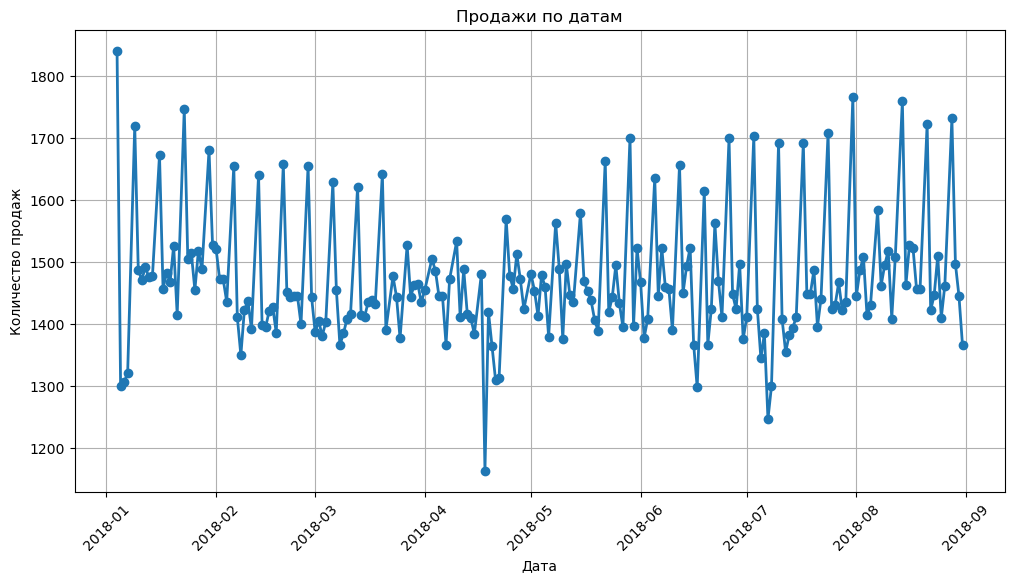

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'], marker='o', linewidth=2)

plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
# Продажи имеют стабильный уровень на протяжении всего периода.
# Среднее количество продаж составляет примерно 1400–1500 в день.
# Наблюдаются регулярные повторяющиеся пики, которые могут свидетельствовать о сезонности внутри недели.
# Встречаются единичные дни с аномально низкими продажами, требующие дополнительного анализа.
# Долгосрочного роста или падения продаж за рассматриваемый период не наблюдается.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

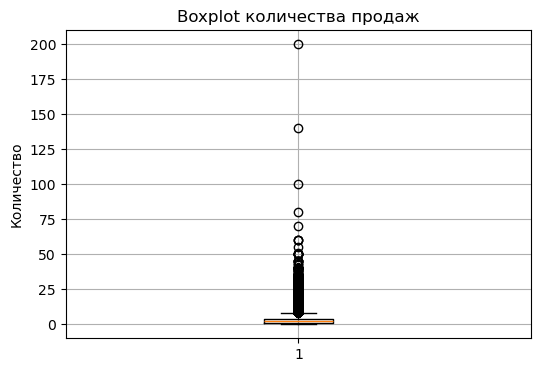

In [20]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['Количество'])
plt.title('Boxplot количества продаж')
plt.ylabel('Количество')
plt.grid(True)
plt.show()

In [21]:
Q1 = df['Количество'].quantile(0.25)
Q3 = df['Количество'].quantile(0.75)

# Межквартильный размах
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Все выбросы
outliers = df[
    (df['Количество'] < lower_bound) |
    (df['Количество'] > upper_bound)
]

print(outliers)

             Дата  Склад   Контрагент Номенклатура  Количество
3      2018-01-04      1    address_0    product_3          10
59     2018-01-04      1    address_3    product_6          10
142    2018-01-04      1   address_10    product_2          10
175    2018-01-04      1   address_14    product_1           9
176    2018-01-04      1   address_14    product_2          10
...           ...    ...          ...          ...         ...
301309 2018-08-31      5  address_169    product_0          10
301310 2018-08-31      5  address_169    product_1          20
301311 2018-08-31      5  address_169    product_2          15
301312 2018-08-31      5  address_169    product_3          10
301315 2018-08-31      5  address_169    product_6          15

[13140 rows x 5 columns]


In [22]:
max_outlier = outliers.loc[outliers['Количество'].idxmax()]

print(max_outlier)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


In [ ]:
# Максимальный статистический выброс по количеству продаж наблюдается 28.06.2018. 
# На складе №1 контрагент address_208 приобрел товар product_0 в количестве 200 единиц. 
# Это значение значительно превышает остальные наблюдения и определяется как выброс по правилу межквартильного размаха (IQR).

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [23]:
df_3 = df[df['Склад'] == 3]

df_3 = df_3[df_3['Дата'].dt.month.isin([6, 7, 8])]

df_3 = df_3[df_3['Дата'].dt.weekday == 2]

top_product = (
    df_3.groupby('Номенклатура')['Количество']
        .sum()
        .sort_values(ascending=False)
)

print(top_product)

Номенклатура
product_1     2267
product_2     2060
product_0     1324
product_3      914
product_6      650
product_4      540
product_22     509
product_5      480
product_13     253
product_15     230
product_17     148
product_11     131
product_10     129
product_12     129
product_18     126
product_19     123
product_7       94
product_8       94
product_21      80
product_20      78
product_23      68
product_14      64
product_16      26
Name: Количество, dtype: int64


In [24]:
top_product = (df_3.groupby('Номенклатура')['Количество'].sum().idxmax())

print("Топовый товар:", top_product)

Топовый товар: product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [39]:
import chardet

with open('weather.csv', 'rb') as f:
    result = chardet.detect(f.read(100000))

print(result)

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [43]:
weather = pd.read_csv(
    'weather.csv',
    encoding='latin1',
    sep=';',
    engine='python'
)

In [31]:
print(weather.head())

  –ú–µ—Å—Ç–Ω–æ–µ –≤—Ä–µ–º—è –≤ –ê—Å—Ç–∞–Ω–µ       T     Po      P      Pa  \
0                          26.06.2026 17:00  31.Ï‡  726.4  755.2    -0.3   
1                          26.06.2026 14:00  30.Ë˛Î  726.7  755.6    -0.4   
2                          26.06.2026 11:00  29.ˇÌ‚  727.1  756.1    -0.2   
3                           26.06.2026 8:00  24.‡Ô  727.3  756.7  01.Ï‡   
4                           26.06.2026 5:00  18.‡Ô  726.0  756.0     0.0   

      U                                        DD  Ff  ff10  ff3  ...  \
0  28.0  –í–µ—Ç–µ—Ä, –¥—É—é—â–∏–π —Å —Å–µ–≤–µ—Ä–∞   2   NaN  NaN  ...   
1  27.0        –í–µ—Ç–µ—Ä, –¥—É—é—â–∏–π —Å —é–≥–∞   2   NaN  NaN  ...   
2  31.0  –í–µ—Ç–µ—Ä, –¥—É—é—â–∏–π —Å —Å–µ–≤–µ—Ä–∞   2   NaN  NaN  ...   
3  54.0            –®—Ç–∏–ª—å, –±–µ–∑–≤–µ—Ç—Ä–∏–µ   0   NaN  NaN  ...   
4  69.0            –®—Ç–∏–ª—å, –±–µ–∑–≤–µ—Ç—Ä–∏–µ   0   NaN  NaN  ...   

                                                  Cm  \
0  –í—ã—Å–æ–∫–æ–∫—É—á–µ–≤—ã–µ –ø—Ä–æ—Å–≤–µ

In [44]:
weather = weather.rename(columns={weather.columns[0]: 'Дата'})

In [45]:
weather = weather[['Дата', 'T']]

In [46]:
weather['Дата'] = pd.to_datetime(
    weather['Дата'],
    format='%d.%m.%Y %H:%M'
).dt.date

In [47]:
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

In [48]:
weather = weather.groupby('Дата', as_index=False)['T'].mean()

In [49]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

In [50]:
merged_df = grouped_df.merge(weather, on='Дата', how='inner')

In [51]:
print(weather.head())


         Дата        T
0  2018-01-01  -9.4625
1  2018-01-02  -9.5125
2  2018-01-03 -11.4625
3  2018-01-04 -14.0750
4  2018-01-05 -16.8625


In [52]:
print(df.head())

        Дата  Склад Контрагент Номенклатура  Количество
0 2018-01-04      1  address_0    product_0           4
1 2018-01-04      1  address_0    product_1           4
2 2018-01-04      1  address_0    product_2           5
3 2018-01-04      1  address_0    product_3          10
4 2018-01-04      1  address_0    product_4           2


In [53]:
print(merged_df.head())

         Дата  Количество продаж        T
0  2018-01-04               1840 -14.0750
1  2018-01-05               1301 -16.8625
2  2018-01-06               1306 -13.3000
3  2018-01-07               1322 -12.7500
4  2018-01-09               1719  -6.2500
